In [15]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [16]:
df = pd.read_csv('/Users/dhruvitjalodhara/programming/ML Practice/Hotel Reservation Prediction/artifacts/cleaned_data.csv')

In [17]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,market_segment_type,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,10,Offline,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,11,Online,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2,Online,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,5,Online,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,4,Online,0,0,94.50,0,Canceled


In [18]:
# 1. Get raw category counts
counts = df['booking_status'].value_counts()

# 2. Get percentages (normalize=True multiplies by 100)
percentages = df['booking_status'].value_counts(normalize=True) * 100

# 3. Print a clean summary
print("--- Class Distribution ---")
for idx in counts.index:
    print(f"Class '{idx}': {counts[idx]} rows ({percentages[idx]:.1f}%)")

--- Class Distribution ---
Class 'Not_Canceled': 24390 rows (67.2%)
Class 'Canceled': 11885 rows (32.8%)


In [19]:
## Independent Feature
x = df.drop(columns=['booking_status'])
x

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,market_segment_type,repeated_guest,no_of_previous_cancellations,avg_price_per_room,no_of_special_requests
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,10,Offline,0,0,65.00,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,11,Online,0,0,106.68,1
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2,Online,0,0,60.00,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,5,Online,0,0,100.00,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,4,Online,0,0,94.50,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,8,Online,0,0,167.80,1
36271,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,10,Online,0,0,90.95,2
36272,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,7,Online,0,0,98.39,2
36273,2,0,0,3,Not Selected,0,Room_Type 1,63,4,Online,0,0,94.50,0


In [20]:
## Dependent Feature 
y = df['booking_status']
y

0        Not_Canceled
1        Not_Canceled
2            Canceled
3            Canceled
4            Canceled
             ...     
36270    Not_Canceled
36271        Canceled
36272    Not_Canceled
36273        Canceled
36274    Not_Canceled
Name: booking_status, Length: 36275, dtype: object

In [21]:
## separate Dataset into train and test
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.35,random_state=42)

x_train.shape , x_test.shape

((23578, 14), (12697, 14))

In [22]:
# Create Column transformer with 3 types of transformers for independnt Feature 
num_features = x_train.select_dtypes(exclude='O').columns
cat_features = x_train.select_dtypes(include='O').columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler 
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    [
        ('OneHotEncoder' , oh_transformer , cat_features),
        ('StandardScaler' , numeric_transformer , num_features)
	]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name``

In [23]:
x_train_transformed = preprocessor.fit_transform(x_train)
x_test_transformed = preprocessor.transform(x_test)


In [24]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)


In [25]:
print("X Shapes (Train/Test):", x_train_transformed.shape, x_test_transformed.shape)
print("Y Shapes (Train/Test):", y_train_encoded.shape, y_test_encoded.shape)

X Shapes (Train/Test): (23578, 27) (12697, 27)
Y Shapes (Train/Test): (23578,) (12697,)


In [26]:
## models 
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , AdaBoostClassifier , GradientBoostingClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

## metrices
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

In [ ]:
def evaluate_model(true, predicted):
    from sklearn.metrics import f1_score
    accuracy = accuracy_score(true,predicted)
    f1 = f1_score(true , predicted , average='binary') ##. default average = binary
    precision = precision_score(true , predicted)
    recall = recall_score(true,predicted)
    rocauc_score = roc_auc_score(true,predicted)
    report = classification_report(true,predicted,target_names=['Not_Canceled', 'Canceled'])

    return accuracy , f1 , precision , recall , rocauc_score , report

In [28]:
models = {
    'Logistic Regression' : LogisticRegression() ,
    'Linear Support Vector Classifier' : LinearSVC() ,
    'Gaussian NB' : GaussianNB() , 
    'KNN Classifier' : KNeighborsClassifier() ,
    'Decision Tree Classifier' : DecisionTreeClassifier() , 
    'Random Forest Classifier' : RandomForestClassifier() ,
    'AdaBoost Classifier' : AdaBoostClassifier() ,
    'Gradient Boosting classifier' : GradientBoostingClassifier() , 
    'XGBoost Classifier' : XGBClassifier(),
    'CatBoost Classifier' : CatBoostClassifier(verbose=False) 
}

model_list = []
test_f1_score = []
train_f1_score = []

for name, model in models.items():
    ## Model Training
    print(f"\n---------- Training Model : {name} ----------  \n")
    model.fit(x_train_transformed, y_train_encoded)

    # Make predictions
    y_train_pred = model.predict(x_train_transformed)
    y_test_pred = model.predict(x_test_transformed)

    # Training set performance
    train_accuracy , train_f1 , train_precision , train_recall ,  train_rocauc_score , train_report = evaluate_model(y_train_encoded , y_train_pred)

    # Test set performance
    test_accuracy , test_f1 , test_precision , test_recall ,  test_rocauc_score , test_report = evaluate_model(y_test_encoded , y_test_pred)

    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(train_accuracy))
    print('- F1 score: {:.4f}'.format(train_f1))
    print('- Precision: {:.4f}'.format(train_precision))
    print('- Recall: {:.4f}'.format(train_recall))
    print('- Roc Auc Score: {:.4f}'.format(train_rocauc_score))
    print(f'Report : \n {train_report}')
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(test_accuracy))
    print('- F1 score: {:.4f}'.format(test_f1))
    print('- Precision: {:.4f}'.format(test_precision))
    print('- Recall: {:.4f}'.format(test_recall))
    print('- Roc Auc Score: {:.4f}'.format(test_rocauc_score))
    print(f'Report : \n {test_report}')
    
    model_list.append(name)
    test_f1_score.append(test_f1)
    train_f1_score.append(train_f1)

    print('\n')
    print('='*35)
    print('\n')


---------- Training Model : Logistic Regression ----------  

Model performance for Training set
- Accuracy: 0.8025
- F1 score: 0.8586
- Precision: 0.8295
- Recall: 0.8899
- Roc Auc Score: 0.7559
Report : 
               precision    recall  f1-score   support

Not_Canceled       0.73      0.62      0.67      7690
    Canceled       0.83      0.89      0.86     15888

    accuracy                           0.80     23578
   macro avg       0.78      0.76      0.77     23578
weighted avg       0.80      0.80      0.80     23578

----------------------------------
Model performance for Test set
- Accuracy: 0.8048
- F1 score: 0.8604
- Precision: 0.8256
- Recall: 0.8983
- Roc Auc Score: 0.7569
Report : 
               precision    recall  f1-score   support

Not_Canceled       0.75      0.62      0.68      4195
    Canceled       0.83      0.90      0.86      8502

    accuracy                           0.80     12697
   macro avg       0.79      0.76      0.77     12697
weighted avg     

In [29]:
score_df = pd.DataFrame(
    {
        'Model Name' : model_list,
        'Train f1' : train_f1_score,
        'Test f1' : test_f1_score
	}
)

score_df['Gap'] = (score_df['Train f1'] - score_df['Test f1']).abs()

safe_models_score = score_df[score_df['Gap'] <= 0.05]

safe_models_score = safe_models_score.sort_values(by=['Test f1'] , ascending=False).reset_index(drop=True)


In [30]:
score_df

,Model Name,Train f1,Test f1,Gap
0,Logistic Regression,0.858592,0.860410,0.001818
1,Linear Support Vector Classifier,0.856632,0.859523,0.002891
2,Gaussian NB,0.245747,0.246484,0.000737
3,KNN Classifier,0.921631,0.892785,0.028846
4,Decision Tree Classifier,0.995468,0.897827,0.097642
5,Random Forest Classifier,0.995445,0.923157,0.072289
6,AdaBoost Classifier,0.862511,0.865794,0.003283
7,Gradient Boosting classifier,0.895925,0.891577,0.004347
8,XGBoost Classifier,0.939181,0.918133,0.021048
9,CatBoost Classifier,0.930820,0.916609,0.014211


In [31]:
safe_models_score

,Model Name,Train f1,Test f1,Gap
0,XGBoost Classifier,0.939181,0.918133,0.021048
1,CatBoost Classifier,0.930820,0.916609,0.014211
2,KNN Classifier,0.921631,0.892785,0.028846
3,Gradient Boosting classifier,0.895925,0.891577,0.004347
4,AdaBoost Classifier,0.862511,0.865794,0.003283
5,Logistic Regression,0.858592,0.860410,0.001818
6,Linear Support Vector Classifier,0.856632,0.859523,0.002891
7,Gaussian NB,0.245747,0.246484,0.000737


In [32]:
## Hyperparameter tunning

In [33]:
lr_params = {
    'penalty' : ['l1', 'l2', 'elasticnet'] ,
    'C' : [10 , 1 , 0.1 , 0.01] ,
    'solver' : ['lbfgs', 'liblinear', 'newton-cg', 'sag', 'saga'] ,
    'class_weight' : ['balanced'],
    'penalty' : ['l1', 'l2', 'elasticnet'],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
    'random_state' : [42],
    'n_jobs' : [-1]
}

linearsvc_params = {
    'loss' : ['squared_hinge', 'hinge'],
    'class_weight' : ['balanced'],
    'penalty' : ['l1', 'l2'],
    'C' : [10 , 1 , 0.1 , 0.01] ,
    'dual': [False],
    'random_state' : [42],
}

knn_params = {
    'n_neighbors' : [5,7,9,10,12,13,15],
    'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'] ,
    'weights' : ['uniform', 'distance'],
    'n_jobs' : [-1]
}

dt_params = {
    'criterion' : ['gini', 'entropy', 'log_loss'] ,
    'splitter' : ['best', 'random'] , 
    'max_depth' : [1,2,3,4,5] ,
    'max_features' : [None, 'sqrt', 'log2'],
    'class_weight' : ['balanced'],
    'random_state' : [42],
}

rf_params = {
    "max_depth": [5, 8, 15, None, 10],
    "max_features": [5, 7, 8 , 'sqrt', 'log2' , None],
    "min_samples_split": [2, 8, 15, 20],
    "n_estimators": [100, 200, 500, 1000],
    'criterion' : ['gini', 'entropy', 'log_loss'],
    'class_weight' : ['balanced'],
    'random_state' : [42],
    'n_jobs' : [-1]
}

ada_params = {
    'n_estimators' : [20,40,50,60,70,80,90,100],
    'learning_rate' : [1,0.1,0.01 , 0.055 , 0.5 , 0.05],
    'random_state' : [42],
}

gb_params = {
    'loss' : ['log_loss', 'exponential'] ,
    'learning_rate' : [1,0.1,0.01 , 0.055 , 0.5 , 0.05],
    'criterion' : ['friedman_mse', 'squared_error'] ,
    'max_features' : [None, 'sqrt', 'log2'] ,
    'n_estimators' : [20,40,50,60,70,80,90,100],
    'subsample': [0.7, 0.8, 1.0],
    'max_depth' : [1,2,3,4,5] ,
    'random_state' : [42],
}

xgb_params = {
    'learning_rate' : [1,0.1,0.01 , 0.055 , 0.5 , 0.05],
    "max_depth": [5, 8, 12, 20, 30],
    "n_estimators": [100, 200, 300],
    "subsample": [0.7, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4]
}

cat_params = {
    'verbose' : [False],
    'learning_rate' : [1,0.1,0.01 , 0.055 , 0.5 , 0.05],
    'auto_class_weights' : ['Balanced'],
    'random_state' : [42],
}

In [34]:
# Models list for Hyperparameter tuning
randomcv_models = [
    ("Logistic Regression" , models['Logistic Regression'] , lr_params) , 
    ("Linear Support Vector Classifier" , models['Linear Support Vector Classifier'] , linearsvc_params) ,
    ("KNN Classifier" , models['KNN Classifier'] , knn_params) ,
    ("Decision Tree Classifier" , models['Decision Tree Classifier'] , dt_params),
    ("Random Forest Classifier" , models['Random Forest Classifier'] , rf_params) ,
    ("AdaBoost Classifier" , models['AdaBoost Classifier'] , ada_params) ,
    ("Gradient Boosting classifier" , models['Gradient Boosting classifier'] , gb_params) ,
    ("XGBoost Classifier" , models['XGBoost Classifier'] , xgb_params) ,
    ("CatBoost Classifier" , models['CatBoost Classifier'] , cat_params)
]

In [35]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}

for name,model,params in randomcv_models:
    random = RandomizedSearchCV(estimator=model , param_distributions=params , n_iter=100 , cv=5 , verbose=2 , n_jobs=-1)
    random.fit(x_train_transformed,y_train_encoded)

    model_params[name] = random.best_params_

Fitting 5 folds for each of 100 candidates, totalling 500 fits
[CV] END C=10, class_weight=balanced, l1_ratio=0.3, n_jobs=-1, penalty=elasticnet, random_state=42, solver=newton-cg; total time=   0.0s
[CV] END C=10, class_weight=balanced, l1_ratio=0.3, n_jobs=-1, penalty=elasticnet, random_state=42, solver=newton-cg; total time=   0.0s
[CV] END C=10, class_weight=balanced, l1_ratio=0.3, n_jobs=-1, penalty=elasticnet, random_state=42, solver=newton-cg; total time=   0.0s
[CV] END C=10, class_weight=balanced, l1_ratio=0.3, n_jobs=-1, penalty=elasticnet, random_state=42, solver=newton-cg; total time=   0.0s
[CV] END C=10, class_weight=balanced, l1_ratio=0.3, n_jobs=-1, penalty=l2, random_state=42, solver=liblinear; total time=   0.1s
[CV] END C=10, class_weight=balanced, l1_ratio=0.3, n_jobs=-1, penalty=elasticnet, random_state=42, solver=newton-cg; total time=   0.0s
[CV] END C=0.01, class_weight=balanced, l1_ratio=0.9, n_jobs=-1, penalty=l1, random_state=42, solver=lbfgs; total time=   0

In [36]:
for model_name in model_params:
    print(f"---------------- Best Params for Model : {model_name} -------------------")
    print(model_params[model_name])

---------------- Best Params for Model : Logistic Regression -------------------
{'solver': 'liblinear', 'random_state': 42, 'penalty': 'l1', 'n_jobs': -1, 'l1_ratio': 0.1, 'class_weight': 'balanced', 'C': 0.1}
---------------- Best Params for Model : Linear Support Vector Classifier -------------------
{'random_state': 42, 'penalty': 'l1', 'loss': 'squared_hinge', 'dual': False, 'class_weight': 'balanced', 'C': 0.01}
---------------- Best Params for Model : KNN Classifier -------------------
{'weights': 'distance', 'n_neighbors': 15, 'n_jobs': -1, 'algorithm': 'auto'}
---------------- Best Params for Model : Decision Tree Classifier -------------------
{'splitter': 'best', 'random_state': 42, 'max_features': None, 'max_depth': 5, 'criterion': 'gini', 'class_weight': 'balanced'}
---------------- Best Params for Model : Random Forest Classifier -------------------
{'random_state': 42, 'n_jobs': -1, 'n_estimators': 500, 'min_samples_split': 2, 'max_features': 7, 'max_depth': None, 'crite

In [37]:
optimized_models = {
    'Logistic Regression' : LogisticRegression(**model_params['Logistic Regression']) ,
    'Linear Support Vector Classifier' : LinearSVC(**model_params['Linear Support Vector Classifier']) ,
    'Gaussian NB' : GaussianNB() ,
    'KNN Classifier' : KNeighborsClassifier(**model_params['KNN Classifier']) ,
    'Decision Tree Classifier' : DecisionTreeClassifier(**model_params['Decision Tree Classifier']) ,
    'Random Forest Classifier' : RandomForestClassifier(**model_params['Random Forest Classifier']) , 
    'AdaBoost Classifier' : AdaBoostClassifier(**model_params['AdaBoost Classifier']) ,
    'Gradient Boosting classifier' : GradientBoostingClassifier(**model_params['Gradient Boosting classifier']) ,
    'XGBoost Classifier' : XGBClassifier(**model_params['XGBoost Classifier']) ,
    'CatBoost Classifier' : XGBClassifier(**model_params['CatBoost Classifier']) ,
}



hypertunned_model_list = []
hypertunned_test_f1_score = []
hypertunned_train_f1_score = []
auc_score = {}

for name, model in models.items():
    ## Model Training
    print(f"\n---------- Training Model : {name} ----------  \n")
    model.fit(x_train_transformed, y_train_encoded)

    # Make predictions
    y_train_pred = model.predict(x_train_transformed)
    y_test_pred = model.predict(x_test_transformed)

    # Training set performance
    train_accuracy , train_f1 , train_precision , train_recall ,  train_rocauc_score , train_report = evaluate_model(y_train_encoded , y_train_pred)

    # Test set performance
    test_accuracy , test_f1 , test_precision , test_recall ,  test_rocauc_score , test_report = evaluate_model(y_test_encoded , y_test_pred)

    
    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(train_accuracy))
    print('- F1 score: {:.4f}'.format(train_f1))
    print('- Precision: {:.4f}'.format(train_precision))
    print('- Recall: {:.4f}'.format(train_recall))
    print('- Roc Auc Score: {:.4f}'.format(train_rocauc_score))
    print(f'Report : \n {train_report}')
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(test_accuracy))
    print('- F1 score: {:.4f}'.format(test_f1))
    print('- Precision: {:.4f}'.format(test_precision))
    print('- Recall: {:.4f}'.format(test_recall))
    print('- Roc Auc Score: {:.4f}'.format(test_rocauc_score))
    print(f'Report : \n {test_report}')
    
    hypertunned_model_list.append(name)
    hypertunned_test_f1_score.append(test_f1)
    hypertunned_train_f1_score.append(train_f1)
    auc_score[name] = test_rocauc_score

    print('\n')
    print('='*35)
    print('\n')


---------- Training Model : Logistic Regression ----------  

Model performance for Training set
- Accuracy: 0.8025
- F1 score: 0.8586
- Precision: 0.8295
- Recall: 0.8899
- Roc Auc Score: 0.7559
Report : 
               precision    recall  f1-score   support

Not_Canceled       0.73      0.62      0.67      7690
    Canceled       0.83      0.89      0.86     15888

    accuracy                           0.80     23578
   macro avg       0.78      0.76      0.77     23578
weighted avg       0.80      0.80      0.80     23578

----------------------------------
Model performance for Test set
- Accuracy: 0.8048
- F1 score: 0.8604
- Precision: 0.8256
- Recall: 0.8983
- Roc Auc Score: 0.7569
Report : 
               precision    recall  f1-score   support

Not_Canceled       0.75      0.62      0.68      4195
    Canceled       0.83      0.90      0.86      8502

    accuracy                           0.80     12697
   macro avg       0.79      0.76      0.77     12697
weighted avg     

In [38]:
hypertunned_score_df = pd.DataFrame(
    {
        'Model Name' : hypertunned_model_list,
        'Train f1' : hypertunned_train_f1_score,
        'Test f1' : hypertunned_test_f1_score
	}
)

hypertunned_score_df['Gap'] = (hypertunned_score_df['Train f1'] - hypertunned_score_df['Test f1']).abs()

hypertunned_safe_models_score = hypertunned_score_df[hypertunned_score_df['Gap'] <= 0.05]

hypertunned_safe_models_score = hypertunned_safe_models_score.sort_values(by=['Test f1'] , ascending=False).reset_index(drop=True)


In [39]:
hypertunned_safe_models_score

,Model Name,Train f1,Test f1,Gap
0,XGBoost Classifier,0.939181,0.918133,0.021048
1,CatBoost Classifier,0.930820,0.916609,0.014211
2,KNN Classifier,0.921631,0.892785,0.028846
3,Gradient Boosting classifier,0.895925,0.891577,0.004347
4,AdaBoost Classifier,0.862511,0.865794,0.003283
5,Logistic Regression,0.858592,0.860410,0.001818
6,Linear Support Vector Classifier,0.856632,0.859523,0.002891
7,Gaussian NB,0.245747,0.246484,0.000737


In [40]:
hypertunned_score_df

,Model Name,Train f1,Test f1,Gap
0,Logistic Regression,0.858592,0.860410,0.001818
1,Linear Support Vector Classifier,0.856632,0.859523,0.002891
2,Gaussian NB,0.245747,0.246484,0.000737
3,KNN Classifier,0.921631,0.892785,0.028846
4,Decision Tree Classifier,0.995468,0.898650,0.096818
5,Random Forest Classifier,0.995476,0.923281,0.072195
6,AdaBoost Classifier,0.862511,0.865794,0.003283
7,Gradient Boosting classifier,0.895925,0.891577,0.004347
8,XGBoost Classifier,0.939181,0.918133,0.021048
9,CatBoost Classifier,0.930820,0.916609,0.014211


In [41]:
# Add the models to the list that you want to view on the ROC plot
auc_models = [
    {
        'label': 'Logistic Regression',
        'model': optimized_models['Logistic Regression']
    },
    {
        'label': 'Linear Support Vector Classifier',
        'model': optimized_models['Linear Support Vector Classifier']
    },
    {
        'label': 'Gaussian NB',
        'model': optimized_models['Gaussian NB']
    },
    {
        'label': 'KNN Classifier',
        'model': optimized_models['KNN Classifier']
    },
    {
        'label': 'Decision Tree Classifier',
        'model': optimized_models['Decision Tree Classifier']
    },
    {
        'label': 'Random Forest Classifier',
        'model': optimized_models['Random Forest Classifier']
    },
    {
        'label': 'AdaBoost Classifier',
        'model': optimized_models['AdaBoost Classifier']
    },
    {
        'label' : 'Gradient Boosting classifier' ,
        'model' : optimized_models['Gradient Boosting classifier']
    },
    {
        'label' : 'XGBoost Classifier' ,
        'model' : optimized_models['XGBoost Classifier']
    },
    {
        'label' : 'CatBoost Classifier' ,
        'model' : optimized_models['CatBoost Classifier']
    },
]

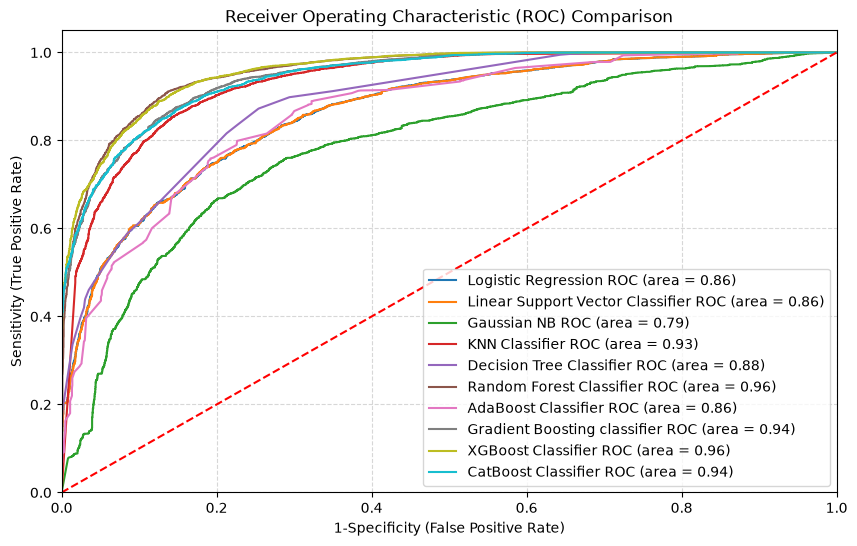

In [42]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for algo in auc_models:
    model = algo['model']
    
    # Optional: Comment this out if your models are already trained to save time!
    model.fit(x_train_transformed, y_train_encoded) 

    # Handle models without predict_proba (like LinearSVC)
    if hasattr(model, "predict_proba"):
        y_scores = model.predict_proba(x_test_transformed)[:, 1]
    elif hasattr(model, "decision_function"):
        y_scores = model.decision_function(x_test_transformed)
    else:
        raise AttributeError(f"Model {algo['label']} doesn't support probability scores.")

    # Calculate actual curve and dynamic AUC score
    fpr, tpr, _ = roc_curve(y_test_encoded, y_scores)
    current_auc = roc_auc_score(y_test_encoded, y_scores)

    # Plot using the freshly calculated AUC score
    plt.plot(fpr, tpr, label=f"{algo['label']} ROC (area = {current_auc:.2f})")

# Custom settings for the plot 
plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('Receiver Operating Characteristic (ROC) Comparison')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


In [43]:
hypertunned_safe_models_score

,Model Name,Train f1,Test f1,Gap
0,XGBoost Classifier,0.939181,0.918133,0.021048
1,CatBoost Classifier,0.930820,0.916609,0.014211
2,KNN Classifier,0.921631,0.892785,0.028846
3,Gradient Boosting classifier,0.895925,0.891577,0.004347
4,AdaBoost Classifier,0.862511,0.865794,0.003283
5,Logistic Regression,0.858592,0.860410,0.001818
6,Linear Support Vector Classifier,0.856632,0.859523,0.002891
7,Gaussian NB,0.245747,0.246484,0.000737


In [44]:
## from df we can say that best model is XGBoost 
xgboost = XGBClassifier(**model_params['XGBoost Classifier'])
xgboost.fit(x_train_transformed,y_train_encoded)
y_pred = xgboost.predict(x_test_transformed)
f1 = f1_score(y_test_encoded,y_pred)
print(f1)


0.92470506592644


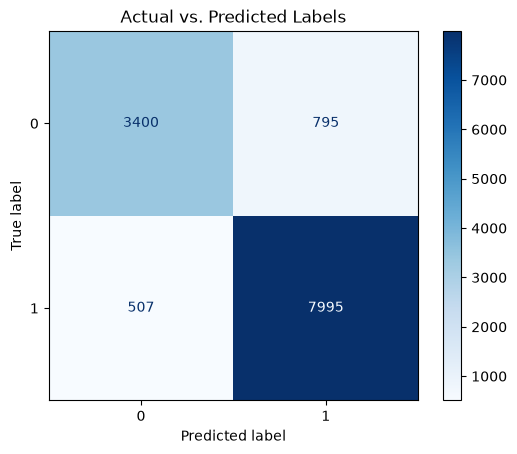

In [45]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generate the confusion matrix data
cm = confusion_matrix(y_test_encoded, y_pred)

# Display it visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)

plt.title('Actual vs. Predicted Labels')
plt.show()


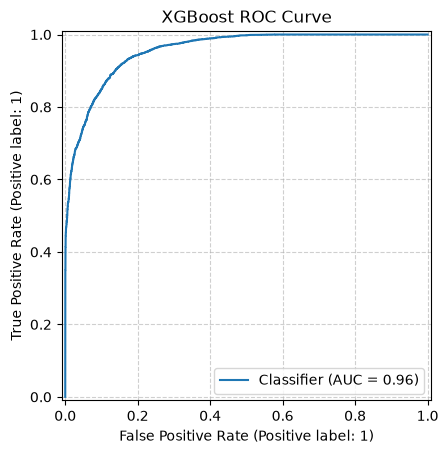

In [46]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

# 1. Get continuous probabilities for Class 1 instead of discrete 0 or 1
y_prob = xgboost.predict_proba(x_test_transformed)[:, 1]

# 2. Plot the ROC Curve
RocCurveDisplay.from_predictions(y_test_encoded, y_prob)
plt.title('XGBoost ROC Curve')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()